 KNN — K-Nearest Neighbours

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import RobustScaler
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.metrics          import (classification_report,
                                       confusion_matrix,
                                       roc_auc_score,
                                       roc_curve)

In [2]:
df = pd.read_csv('credit_card_transactions.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print('Rows:', len(df))
print('Columns:', len(df.columns))

Rows: 1296675
Columns: 23


In [3]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

# Infer payment mode from category name
df['spend_mode'] = df['category'].apply(
    lambda x: 'Online'  if str(x).endswith('_net') else
             ('InStore' if str(x).endswith('_pos') else 'Other')
)

print('Date and age columns created.')

Date and age columns created.


In [4]:
# Remove outliers
for col in ['amt', 'age', 'city_pop']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print('Rows after outlier removal:', len(df))

Rows after outlier removal: 1000070


In [5]:
# Aggregate to one row per customer
ref_date = df['trans_date_trans_time'].max() + pd.Timedelta(days=1)

rfm = df.groupby('cc_num').agg(
    Recency     = ('trans_date_trans_time', lambda x: (ref_date - x.max()).days),
    Frequency   = ('trans_num', 'count'),
    Monetary    = ('amt', 'sum'),
    Avg_Amt     = ('amt', 'mean'),
    Fraud_Rate  = ('is_fraud', 'mean'),
    Unique_Cats = ('category', 'nunique'),
    Online_Pct  = ('spend_mode', lambda x: (x == 'Online').mean()),
    Avg_Age     = ('age', 'mean'),
    Gender      = ('gender', 'first'),
).reset_index()

rfm['Recency_log']  = np.log1p(rfm['Recency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Gender_enc']   = (rfm['Gender'] == 'M').astype(int)

print('Customer table ready:', rfm.shape)

Customer table ready: (781, 13)



Customers in the **top 25% of fraud rate** get label `1` (High Fraud Risk).  
Everyone else gets label `0` (Low Fraud Risk).

In [6]:
# Find the top 25% cutoff
cutoff = rfm['Fraud_Rate'].quantile(0.75)
print('Cutoff value (top 25%):', round(cutoff, 4))

Cutoff value (top 25%): 0.003


In [7]:
rfm['High_Fraud_Risk'] = (rfm['Fraud_Rate'] >= cutoff).astype(int)

print('Label counts:')
print(rfm['High_Fraud_Risk'].value_counts())
print()
print('0 = Low Fraud Risk  (most customers)')
print('1 = High Fraud Risk (top 25% by fraud rate)')

Label counts:
High_Fraud_Risk
0    585
1    196
Name: count, dtype: int64

0 = Low Fraud Risk  (most customers)
1 = High Fraud Risk (top 25% by fraud rate)


In [8]:
features = [
    'Recency_log',   # how recently they transacted
    'Frequency',     # how many transactions
    'Monetary_log',  # how much they spent
    'Avg_Amt',       # average single transaction amount
    'Online_Pct',    # share of online transactions
    'Unique_Cats',   # how many different spending categories
    'Avg_Age',       # customer age
    'Gender_enc',    # 0 = Female, 1 = Male
]

X = rfm[features]
y = rfm['High_Fraud_Risk']

print('Features (X):', X.shape)
print('Target   (y):', y.shape)

Features (X): (781, 8)
Target   (y): (781,)


Split into training and test sets


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size  = 0.25,
    random_state = 42,
    stratify   = y       # keeps the same fraud ratio in both sets
)

print('Training set:', X_train.shape[0], 'customers')
print('Test set    :', X_test.shape[0],  'customers')
print()
print('Fraud rate in training set:', round(y_train.mean(), 3))
print('Fraud rate in test set    :', round(y_test.mean(), 3))
print('(These should be close to each other)')

Training set: 585 customers
Test set    : 196 customers

Fraud rate in training set: 0.251
Fraud rate in test set    : 0.25
(These should be close to each other)



 Scale the features



In [10]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn the scale from training only
X_test_scaled  = scaler.transform(X_test)         # apply the same scale to test

print('Scaling done.')

Scaling done.


 Find the best K


In [11]:
print('K    F1-Score')
print('---  --------')

k_values = [3, 5, 7, 9, 11, 13]
f1_scores = []

for k in k_values:
    model  = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    f1_scores.append(scores.mean())
    print(f'{k:2d}    {scores.mean():.3f}')

K    F1-Score
---  --------
 3    0.509
 5    0.509
 7    0.543
 9    0.557
11    0.508
13    0.518


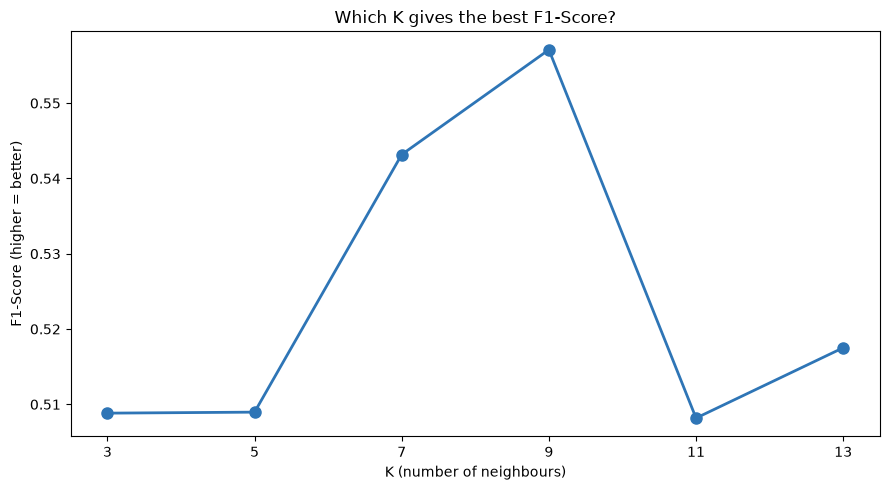

Best K: 9


In [12]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, f1_scores, marker='o', color='#2E75B6', linewidth=2, markersize=8)
plt.title('Which K gives the best F1-Score?')
plt.xlabel('K (number of neighbours)')
plt.ylabel('F1-Score (higher = better)')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[f1_scores.index(max(f1_scores))]
print('Best K:', best_k)

 Train the final model

In [13]:
# Change BEST_K to whatever the cross-validation showed
BEST_K = 9

knn = KNeighborsClassifier(n_neighbors=BEST_K)
knn.fit(X_train_scaled, y_train)

print(f'Model trained with K = {BEST_K}')
print(f'Trained on {X_train_scaled.shape[0]} customers')

Model trained with K = 9
Trained on 585 customers


Make predictions

In [14]:
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

print('Predictions made on', len(y_pred), 'customers')
print()
print('Predicted High Fraud Risk:', y_pred.sum())
print('Actual   High Fraud Risk :', y_test.sum())

Predictions made on 196 customers

Predicted High Fraud Risk: 31
Actual   High Fraud Risk : 49


Evaluate the model

- **Precision** = of all customers we flagged, how many were actually high risk?
- **Recall** = of all actual high-risk customers, how many did we catch?
- **F1-Score** = one number that balances precision and recall

In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Low Fraud Risk', 'High Fraud Risk']
))

                 precision    recall  f1-score   support

 Low Fraud Risk       0.85      0.95      0.90       147
High Fraud Risk       0.77      0.49      0.60        49

       accuracy                           0.84       196
      macro avg       0.81      0.72      0.75       196
   weighted avg       0.83      0.84      0.82       196



 Confusion Matrix

This shows exactly where the model got things right and wrong.

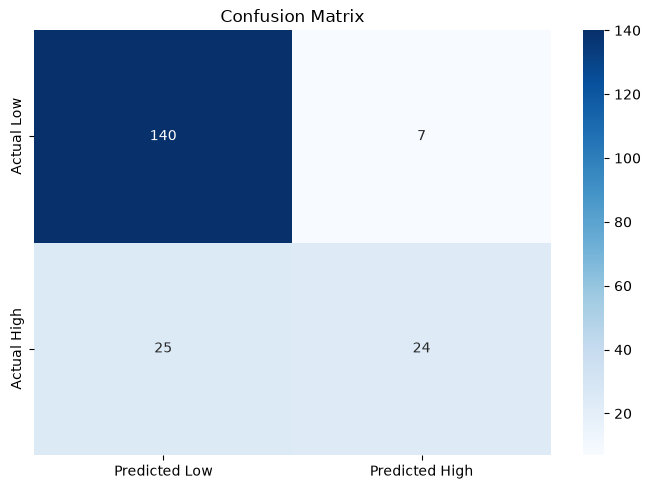

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Low', 'Predicted High'],
    yticklabels=['Actual Low',    'Actual High']
)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [17]:
tn, fp, fn, tp = cm.ravel()

print('Reading the confusion matrix:')
print()
print(f'  {tn}  correctly identified as low risk')
print(f'  {fp}  flagged as high risk but were actually low risk  (false alarm)')
print(f'  {fn}  missed — were high risk but predicted low risk   (worst case!)')
print(f'  {tp}  correctly caught as high risk')
print()
print('For fraud detection, missed high-risk customers (false negatives) are the biggest problem.')

Reading the confusion matrix:

  140  correctly identified as low risk
  7  flagged as high risk but were actually low risk  (false alarm)
  25  missed — were high risk but predicted low risk   (worst case!)
  24  correctly caught as high risk

For fraud detection, missed high-risk customers (false negatives) are the biggest problem.


 Summary

In [21]:
accuracy    = (y_pred == y_test).mean()
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
recall      = tp / (tp + fn) if (tp + fn) > 0 else 0

print('=== KNN Final Results ===')
print()
print(f'K used            : {BEST_K}')
print(f'Accuracy          : {accuracy*100:.1f}%')
print(f'AUC-ROC           : {round(auc, 3)}')
print(f'High-risk caught  : {tp} out of {tp+fn} ({recall*100:.0f}% recall)')
print(f'False alarms      : {fp}')
print(f'Missed high-risk  : {fn}')
print()
print('The most important number for fraud detection is recall.')
print('Higher recall = catching more actual high-risk customers.')

# Save
results = rfm[['cc_num', 'High_Fraud_Risk']].copy()
results['Predicted']   = knn.predict(scaler.transform(rfm[features]))
results['Probability'] = knn.predict_proba(scaler.transform(rfm[features]))[:, 1].round(3)
results.to_csv('cc_knn_output.csv', index=False)
print()
print('Saved: cc_knn_output.csv')

=== KNN Final Results ===

K used            : 9
Accuracy          : 83.7%
AUC-ROC           : 0.847
High-risk caught  : 24 out of 49 (49% recall)
False alarms      : 7
Missed high-risk  : 25

The most important number for fraud detection is recall.
Higher recall = catching more actual high-risk customers.

Saved: cc_knn_output.csv
